In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

In [59]:
from google.colab import drive
import os

drive.mount("/content/drive", force_remount=False)

# quick sanity check
assert os.path.isdir("/content/drive/MyDrive"), "Drive mount failed: /content/drive/MyDrive not found"
print("Drive mounted. MyDrive is available at /content/drive/MyDrive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. MyDrive is available at /content/drive/MyDrive


In [60]:
#import os
#os.listdir('/content/drive/MyDrive')

In [61]:
import os

target = "europe_yearly.csv"
search_root = "/content/drive/MyDrive"

matches = []
for root, _, files in os.walk(search_root):
    if target in files:
        matches.append(os.path.join(root, target))

if not matches:
    raise FileNotFoundError(
        f"Could not find '{target}' anywhere under {search_root}. "
        "Check the filename (case-sensitive) and that the file is in MyDrive."
    )

print("Found file at:")
for p in matches:
    print(" -", p)

matches

Found file at:
 - /content/drive/MyDrive/europe_yearly.csv


['/content/drive/MyDrive/europe_yearly.csv']

In [62]:
#import os
#target="europe_yearly.csv"
#matches=[]
#for root, dirs, files in os.walk("europe_yearly.csv"):
#  if target in files:
 #   matches.append(os.path.join(root, target))
#matches

In [63]:
import os

path = matches[0]
if not os.path.exists(path):
    raise FileNotFoundError(f"Path does not exist: {path}")

df = pd.read_csv(path, low_memory=False)

print("Loaded:", path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

display(df.head(20))

Loaded: /content/drive/MyDrive/europe_yearly.csv
Shape: (69310, 18)
Columns: ['Area', 'ISO 3 code', 'Year', 'Area type', 'Continent', 'Ember region', 'EU', 'OECD', 'G20', 'G7', 'ASEAN', 'Category', 'Subcategory', 'Variable', 'Unit', 'Value', 'YoY absolute change', 'YoY % change']


,Area,ISO 3 code,Year,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity demand,Demand,Demand,TWh,48.81,NaN,NaN
1,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity demand,Demand per capita,Demand per capita,MWh,6.36,NaN,NaN
2,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Clean,%,66.25,NaN,NaN
3,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Coal,%,12.56,NaN,NaN
4,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Fossil,%,33.75,NaN,NaN
5,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,"Hydro, bioenergy and other renewables",%,66.25,NaN,NaN
6,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Renewables,%,66.25,NaN,NaN
7,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Wind,%,0.00,NaN,NaN
8,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Wind and solar,%,0.00,NaN,NaN
9,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Clean,TWh,32.64,NaN,NaN


In [64]:
mask = (
    df["Category"].fillna("").str.strip().eq("Electricity demand") &
    df["Variable"].fillna("").str.strip().eq("Demand") &
    df["Unit"].fillna("").str.strip().eq("TWh")
)

rows_per_area = (
    df.loc[mask]
      .groupby("Area", dropna=False)
      .size()
      .sort_values(ascending=False)
)

print(f"Total rows matching Electricity demand / Demand / TWh: {rows_per_area.sum()}")
display(rows_per_area.head(20))

Total rows matching Electricity demand / Demand / TWh: 1320


,0
Area,
Austria,36
Belgium,36
Bulgaria,36
Croatia,36
Cyprus,36
Czechia,36
Türkiye,36
Denmark,36
EU,36


In [65]:
# ---- 1) Clean column names (keep meaning for % by converting to 'pct') ----
df.columns = (
    df.columns
      .str.strip()
      .str.replace("%", "pct", regex=False)            # YoY % change -> YoY pct change
      .str.replace(r"\s+", "_", regex=True)            # spaces/tabs -> _
      .str.replace(r"[^0-9a-zA-Z_]+", "", regex=True)  # drop non-alnum except _
      .str.lower()
)

# ---- 2) Trim whitespace in text columns safely ----
text_cols = df.select_dtypes(include=["object", "string"]).columns
df[text_cols] = df[text_cols].apply(lambda s: s.astype("string").str.strip())

# ---- 3) Convert numeric columns safely ----
# Note: after renaming %, the column is likely 'yoy_pct_change'
num_cols = ["eu", "oecd", "g20", "g7", "asean", "value", "yoy_absolute_change", "yoy_pct_change"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ---- 4) Year to nullable integer ----
if "year" in df.columns:
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

# ---- 5) Convert membership flags to boolean (handles 0/1 or True/False) ----
flag_cols = ["eu", "oecd", "g20", "g7", "asean"]
for c in flag_cols:
    if c in df.columns:
        # If already boolean-like, this will keep it; if 0/1 numeric, it converts properly
        df[c] = df[c].map({1: True, 0: False, True: True, False: False}).astype("boolean")

In [66]:
display(df.head(50))

,area,iso_3_code,year,area_type,continent,ember_region,eu,oecd,g20,g7,asean,category,subcategory,variable,unit,value,yoy_absolute_change,yoy_pct_change
0,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity demand,Demand,Demand,TWh,48.81,NaN,NaN
1,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity demand,Demand per capita,Demand per capita,MWh,6.36,NaN,NaN
2,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity generation,Aggregate fuel,Clean,%,66.25,NaN,NaN
3,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity generation,Aggregate fuel,Coal,%,12.56,NaN,NaN
4,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity generation,Aggregate fuel,Fossil,%,33.75,NaN,NaN
5,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity generation,Aggregate fuel,"Hydro, bioenergy and other renewables",%,66.25,NaN,NaN
6,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity generation,Aggregate fuel,Renewables,%,66.25,NaN,NaN
7,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity generation,Aggregate fuel,Wind,%,0.00,NaN,NaN
8,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity generation,Aggregate fuel,Wind and solar,%,0.00,NaN,NaN
9,Austria,AUT,1990,Country or economy,Europe,Europe,True,True,False,False,False,Electricity generation,Aggregate fuel,Clean,TWh,32.64,NaN,NaN


In [67]:
# Extract electricity demand (TWh) for a given country
country = "Austria"   # change to another area if needed

demand = df[
    (df["category"].fillna("").eq("Electricity demand")) &
    (df["variable"].fillna("").eq("Demand")) &
    (df["unit"].fillna("").eq("TWh")) &
    (df["area"].fillna("").eq(country))
].copy()

# Keep only relevant columns + rename target
demand = (
    demand[["area", "iso_3_code", "year", "value"]]
      .rename(columns={"value": "demand_TWh"})
      .sort_values(["area", "year"])
      .reset_index(drop=True)
)

# Ensure correct dtypes
demand["year"] = pd.to_numeric(demand["year"], errors="coerce").astype("Int64")
demand["demand_TWh"] = pd.to_numeric(demand["demand_TWh"], errors="coerce")

# Drop rows missing essentials
demand = demand.dropna(subset=["year", "demand_TWh"])

# Check for duplicates (same area-year should appear once)
dups = demand.duplicated(subset=["area", "year"]).sum()
if dups:
    print(f"Warning: found {dups} duplicate area-year rows; averaging duplicates.")
    demand = demand.groupby(["area", "iso_3_code", "year"], as_index=False)["demand_TWh"].mean()

display(demand.head(20))
print("Rows:", len(demand), "| Years:", int(demand["year"].min()), "-", int(demand["year"].max()))

,area,iso_3_code,year,demand_TWh
0,Austria,AUT,1990,48.81
1,Austria,AUT,1991,50.93
2,Austria,AUT,1992,50.44
3,Austria,AUT,1993,50.58
4,Austria,AUT,1994,51.13
5,Austria,AUT,1995,52.58
6,Austria,AUT,1996,54.40
7,Austria,AUT,1997,54.82
8,Austria,AUT,1998,55.66
9,Austria,AUT,1999,57.82


Rows: 36 | Years: 1990 - 2025


In [68]:
# Select one country's series (Austria) and ensure it's sorted properly
iso = "AUT"
a = (
    demand[demand["iso_3_code"] == iso]
      .sort_values("year")
      .reset_index(drop=True)
)

# Make sure year is numeric
a["year"] = pd.to_numeric(a["year"], errors="coerce").astype("Int64")
a = a.dropna(subset=["year", "demand_TWh"]).copy()

test_years = 5
if len(a) <= test_years:
    raise ValueError(f"Not enough rows for test_years={test_years}. Rows available: {len(a)}")

# Time-based split (last N years as test)
train = a.iloc[:-test_years].copy()
test  = a.iloc[-test_years:].copy()

# scikit-learn expects X as 2D and y as 1D
X_train = train[["year"]]
y_train = train["demand_TWh"]

X_test  = test[["year"]]
y_test  = test["demand_TWh"]

print(f"{iso} | Train years: {int(train['year'].min())}–{int(train['year'].max())} (n={len(train)})")
print(f"{iso} | Test  years: {int(test['year'].min())}–{int(test['year'].max())} (n={len(test)})")

AUT | Train years: 1990–2020 (n=31)
AUT | Test  years: 2021–2025 (n=5)


In [69]:
# 1) Fit linear regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# 2) Evaluate on test set
y_pred = lin_model.predict(X_test)

mae  = float(mean_absolute_error(y_test, y_pred))
mape = float(mean_absolute_percentage_error(y_test, y_pred))
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))

metrics_linear = pd.DataFrame([{
    "model": "LinearRegression",
    "MAE (TWh)": round(mae, 2),
    "RMSE (TWh)": round(rmse, 2),
    "MAPE (%)": round(mape * 100, 2),
    "test_years": len(test),
    "test_start": int(test["year"].min()),
    "test_end": int(test["year"].max()),
}])

display(metrics_linear)

# 3) Forecast next N years
horizon = 5
last_year = int(a["year"].max())

future_years = np.arange(last_year + 1, last_year + 1 + horizon)
future_X = pd.DataFrame({"year": future_years})  # keeps feature name
future_pred = lin_model.predict(future_X)

forecast_linear = pd.DataFrame({
    "area": a["area"].iloc[0],
    "iso_3_code": a["iso_3_code"].iloc[0],
    "year": future_years.astype(int),
    "demand_TWh": future_pred.astype(float),
    "type": "forecast",
})
forecast_linear["demand_TWh"] = forecast_linear["demand_TWh"].round(2)

# 4) Combine last 10 actual years + linear forecast
history_tail = a[["area", "iso_3_code", "year", "demand_TWh"]].tail(10).copy()
history_tail["type"] = "actual"
history_tail["year"] = history_tail["year"].astype(int)
history_tail["demand_TWh"] = history_tail["demand_TWh"].astype(float).round(2)

combined_linear = (
    pd.concat([history_tail, forecast_linear], ignore_index=True)
      .sort_values(["year", "type"])
)

display(combined_linear)

,model,MAE (TWh),RMSE (TWh),MAPE (%),test_years,test_start,test_end
0,LinearRegression,6.22,6.56,8.52,5,2021,2025


,area,iso_3_code,year,demand_TWh,type
0,Austria,AUT,2016,72.03,actual
1,Austria,AUT,2017,73.64,actual
2,Austria,AUT,2018,73.62,actual
3,Austria,AUT,2019,73.82,actual
4,Austria,AUT,2020,71.23,actual
5,Austria,AUT,2021,74.21,actual
6,Austria,AUT,2022,73.18,actual
7,Austria,AUT,2023,71.21,actual
8,Austria,AUT,2024,71.99,actual
9,Austria,AUT,2025,77.33,actual


In [70]:
def make_poly_model(degree: int, ridge_alpha=None):
    """Polynomial regression (optionally Ridge-regularized)."""
    if ridge_alpha is None:
        return Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("lr", LinearRegression()),
        ])
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("ridge", Ridge(alpha=ridge_alpha)),
    ])

def eval_model(model, X_test, y_test):
    pred = model.predict(X_test)
    mae  = float(mean_absolute_error(y_test, pred))
    mape = float(mean_absolute_percentage_error(y_test, pred))
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    return mae, mape, rmse, pred

def make_forecast_table(a, model, horizon=5):
    last_year = int(a["year"].max())
    future_years = np.arange(last_year + 1, last_year + 1 + horizon)
    X_future = pd.DataFrame({"year": future_years})
    future_pred = model.predict(X_future)

    out = pd.DataFrame({
        "area": a["area"].iloc[0],
        "iso_3_code": a["iso_3_code"].iloc[0],
        "year": future_years.astype(int),
        "demand_TWh": future_pred.astype(float),
        "type": "forecast",
    })
    out["demand_TWh"] = out["demand_TWh"].round(2)
    return out

# Evaluate degrees 1–3
degrees = [1, 2, 3]
rows = []

for deg in degrees:
    poly = make_poly_model(deg)  # if you want Ridge: make_poly_model(deg, ridge_alpha=1.0)
    poly.fit(X_train, y_train)
    mae, mape, rmse, _ = eval_model(poly, X_test, y_test)

    rows.append({
        "degree": deg,
        "MAE (TWh)": round(mae, 2),
        "RMSE (TWh)": round(rmse, 2),
        "MAPE (%)": round(mape * 100, 2),
    })

poly_results = pd.DataFrame(rows).sort_values("MAPE (%)")
display(poly_results)

best_degree = int(poly_results.iloc[0]["degree"])
best_model = make_poly_model(best_degree)
best_model.fit(X_train, y_train)

print(f"Selected polynomial degree: {best_degree}")

horizon = 5
forecast_best = make_forecast_table(a, best_model, horizon=horizon)
display(forecast_best)

,degree,MAE (TWh),RMSE (TWh),MAPE (%)
1,2,1.91,2.22,2.60
2,3,4.91,5.94,6.56
0,1,6.22,6.56,8.52


Selected polynomial degree: 2


,area,iso_3_code,year,demand_TWh,type
0,Austria,AUT,2026,74.33,forecast
1,Austria,AUT,2027,74.26,forecast
2,Austria,AUT,2028,74.15,forecast
3,Austria,AUT,2029,73.99,forecast
4,Austria,AUT,2030,73.78,forecast


In [71]:
def eval_basic(model, X_test, y_test):
    pred = model.predict(X_test)
    mae  = float(mean_absolute_error(y_test, pred))
    mape = float(mean_absolute_percentage_error(y_test, pred))
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    return mae, mape, rmse

rows = []

# Linear baseline
lin = LinearRegression().fit(X_train, y_train)
mae, mape, rmse = eval_basic(lin, X_test, y_test)
rows.append({"model": "LinearRegression", "degree": 1,
             "MAE (TWh)": round(mae, 2), "RMSE (TWh)": round(rmse, 2), "MAPE (%)": round(mape*100, 2)})

# Polynomial degrees 2–3
for deg in [2, 3]:
    poly = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("lr", LinearRegression())
    ]).fit(X_train, y_train)

    mae, mape, rmse = eval_basic(poly, X_test, y_test)
    rows.append({"model": f"Poly(degree={deg})", "degree": deg,
                 "MAE (TWh)": round(mae, 2), "RMSE (TWh)": round(rmse, 2), "MAPE (%)": round(mape*100, 2)})

comparison = pd.DataFrame(rows).sort_values(["MAPE (%)", "RMSE (TWh)"]).reset_index(drop=True)
display(comparison)

,model,degree,MAE (TWh),RMSE (TWh),MAPE (%)
0,Poly(degree=2),2,1.91,2.22,2.60
1,Poly(degree=3),3,4.91,5.94,6.56
2,LinearRegression,1,6.22,6.56,8.52


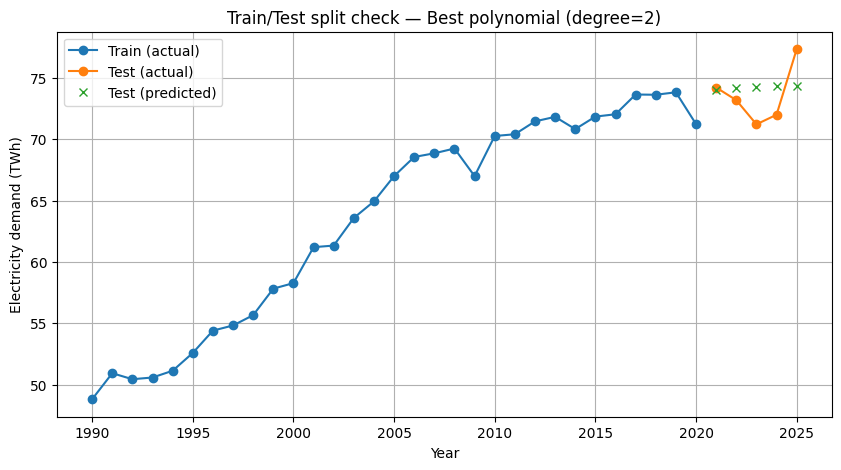

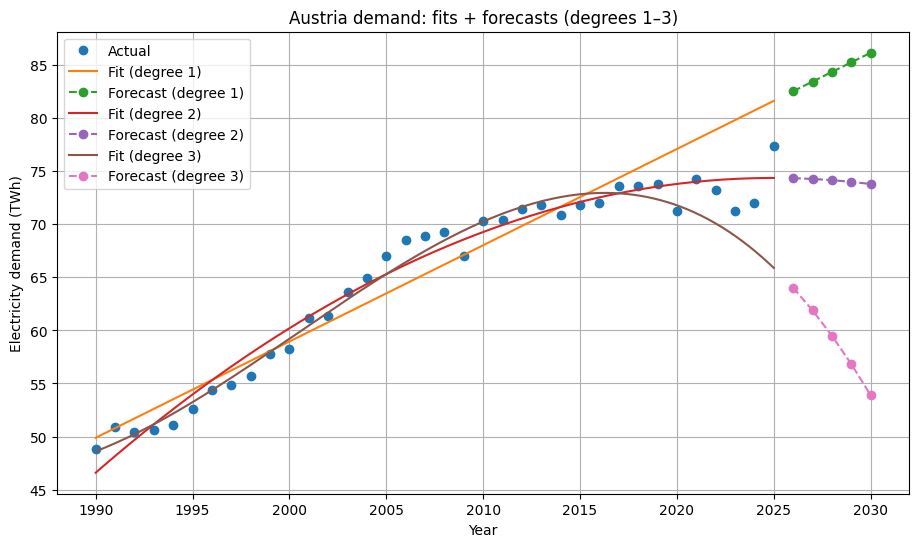

,area,iso_3_code,year,demand_TWh,type
0,Austria,AUT,2016,72.03,actual
1,Austria,AUT,2017,73.64,actual
2,Austria,AUT,2018,73.62,actual
3,Austria,AUT,2019,73.82,actual
4,Austria,AUT,2020,71.23,actual
5,Austria,AUT,2021,74.21,actual
6,Austria,AUT,2022,73.18,actual
7,Austria,AUT,2023,71.21,actual
8,Austria,AUT,2024,71.99,actual
9,Austria,AUT,2025,77.33,actual


In [72]:
# 1) Train/Test diagnostic plot for the selected best polynomial model
_, _, _, test_pred = eval_model(best_model, X_test, y_test)

plt.figure(figsize=(10, 5))
plt.plot(train["year"].astype(int), train["demand_TWh"], marker="o", label="Train (actual)")
plt.plot(test["year"].astype(int),  test["demand_TWh"],  marker="o", label="Test (actual)")
plt.plot(test["year"].astype(int),  test_pred,           marker="x", linestyle="None", label="Test (predicted)")
plt.xlabel("Year")
plt.ylabel("Electricity demand (TWh)")
plt.title(f"Train/Test split check — Best polynomial (degree={best_degree})")
plt.legend()
plt.grid(True)
plt.show()

# 2) Plot fitted curves + forecasts for degrees 1–3 (to discuss under/overfitting)
a_sorted = a.sort_values("year").reset_index(drop=True)
years_hist = a_sorted["year"].astype(int).values
y_hist = a_sorted["demand_TWh"].values

grid_years = np.linspace(years_hist.min(), years_hist.max(), 300)
X_grid = pd.DataFrame({"year": grid_years})

horizon = 5
future_years = np.arange(years_hist.max() + 1, years_hist.max() + 1 + horizon)
X_future = pd.DataFrame({"year": future_years})

plt.figure(figsize=(11, 6))
plt.plot(years_hist, y_hist, marker="o", linestyle="None", label="Actual")

for deg in [1, 2, 3]:
    m = make_poly_model(deg)
    m.fit(X_train, y_train)

    plt.plot(grid_years, m.predict(X_grid), label=f"Fit (degree {deg})")
    plt.plot(future_years, m.predict(X_future), marker="o", linestyle="--", label=f"Forecast (degree {deg})")

plt.xlabel("Year")
plt.ylabel("Electricity demand (TWh)")
plt.title("Austria demand: fits + forecasts (degrees 1–3)")
plt.grid(True)
plt.legend()
plt.show()

# 3) Combine last 10 actual years + forecast_best
history_tail = a_sorted[["area", "iso_3_code", "year", "demand_TWh"]].tail(10).copy()
history_tail["type"] = "actual"
history_tail["year"] = history_tail["year"].astype(int)
history_tail["demand_TWh"] = history_tail["demand_TWh"].astype(float).round(2)

combined_best = (
    pd.concat([history_tail, forecast_best], ignore_index=True)
      .sort_values(["year", "type"])
)

display(combined_best)

,area,iso_3_code,year,demand_TWh,type
0,Austria,AUT,2026,74.33,forecast
1,Austria,AUT,2027,74.26,forecast
2,Austria,AUT,2028,74.15,forecast
3,Austria,AUT,2029,73.99,forecast
4,Austria,AUT,2030,73.78,forecast


,area,iso_3_code,year,demand_TWh,type
0,Austria,AUT,2016,72.03,actual
1,Austria,AUT,2017,73.64,actual
2,Austria,AUT,2018,73.62,actual
3,Austria,AUT,2019,73.82,actual
4,Austria,AUT,2020,71.23,actual
5,Austria,AUT,2021,74.21,actual
6,Austria,AUT,2022,73.18,actual
7,Austria,AUT,2023,71.21,actual
8,Austria,AUT,2024,71.99,actual
9,Austria,AUT,2025,77.33,actual


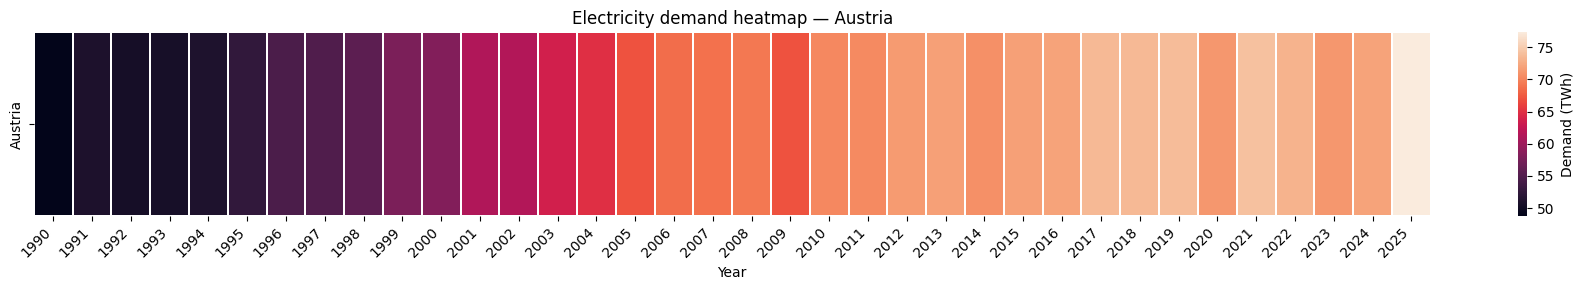

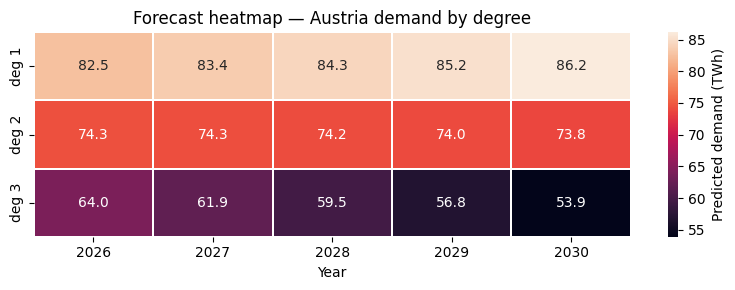

In [73]:


# Fit best model
best_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("lr", LinearRegression())
]).fit(X_train, y_train)

# Forecast next N years with best model
horizon = 5
last_year = int(a["year"].max())
future_years = np.arange(last_year + 1, last_year + 1 + horizon)
X_future = pd.DataFrame({"year": future_years})
future_pred = best_poly.predict(X_future)

forecast_best = pd.DataFrame({
    "area": a["area"].iloc[0],
    "iso_3_code": a["iso_3_code"].iloc[0],
    "year": future_years.astype(int),
    "demand_TWh": future_pred.astype(float),
    "type": "forecast",
})
forecast_best["demand_TWh"] = forecast_best["demand_TWh"].round(2)

# Combine last 10 actual years + best forecast
history_tail = a[["area", "iso_3_code", "year", "demand_TWh"]].tail(10).copy()
history_tail["type"] = "actual"
history_tail["year"] = history_tail["year"].astype(int)
history_tail["demand_TWh"] = history_tail["demand_TWh"].astype(float).round(2)

combined_best = (
    pd.concat([history_tail, forecast_best], ignore_index=True)
      .sort_values(["year", "type"])
)
display(forecast_best)
display(combined_best)

# ---- Heatmap 1: actual demand over years (single row heatmap) ----
heatmap_pivot = a.assign(country=country).pivot(index="country", columns="year", values="demand_TWh")
plt.figure(figsize=(18, 3))
sns.heatmap(heatmap_pivot, annot=False, linewidths=0.3, linecolor="white", cbar_kws={"label": "Demand (TWh)"})
plt.title("Electricity demand heatmap — Austria")
plt.xlabel("Year")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---- Heatmap 2: forecast by degree (1–3) ----
heatmap_data = {}
for deg in [1, 2, 3]:
    m = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("lr", LinearRegression())
    ]).fit(X_train, y_train)
    heatmap_data[f"deg {deg}"] = m.predict(X_future).round(2)

forecast_heatmap = pd.DataFrame(heatmap_data, index=future_years).T
forecast_heatmap.index.name = "degree"
forecast_heatmap.columns.name = "year"

plt.figure(figsize=(8, 3))
sns.heatmap(forecast_heatmap, annot=True, fmt=".1f", linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Predicted demand (TWh)"})
plt.title("Forecast heatmap — Austria demand by degree")
plt.xlabel("Year")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Energy Consumption and prediction for United Kingdom**

In [74]:
country = "United Kingdom"
iso = "GBR"

uk = df[
    (df["category"].fillna("").eq("Electricity demand")) &
    (df["variable"].fillna("").eq("Demand")) &
    (df["unit"].fillna("").eq("TWh")) &
    (df["area"].fillna("").eq(country))
].copy()

uk = (
    uk[["area", "iso_3_code", "year", "value"]]
      .rename(columns={"value": "demand_TWh"})
      .sort_values(["year"])
      .reset_index(drop=True)
)

# Ensure numeric
uk["year"] = pd.to_numeric(uk["year"], errors="coerce").astype("Int64")
uk["demand_TWh"] = pd.to_numeric(uk["demand_TWh"], errors="coerce")
uk = uk.dropna(subset=["year", "demand_TWh"]).copy()

# Optional: collapse duplicates if any (same year repeated)
dups = uk.duplicated(subset=["year"]).sum()
if dups:
    print(f"Warning: {dups} duplicate year rows found; averaging duplicates.")
    uk = uk.groupby(["area", "iso_3_code", "year"], as_index=False)["demand_TWh"].mean()

display(uk.head(20))
print("Rows:", len(uk), "| Years:", int(uk["year"].min()), "-", int(uk["year"].max()))

,area,iso_3_code,year,demand_TWh
0,United Kingdom,GBR,1990,331.69
1,United Kingdom,GBR,1991,339.29
2,United Kingdom,GBR,1992,337.73
3,United Kingdom,GBR,1993,339.83
4,United Kingdom,GBR,1994,343.45
5,United Kingdom,GBR,1995,353.73
6,United Kingdom,GBR,1996,367.62
7,United Kingdom,GBR,1997,367.24
8,United Kingdom,GBR,1998,375.42
9,United Kingdom,GBR,1999,382.39


Rows: 36 | Years: 1990 - 2025


In [75]:
test_years = 5

a = uk.sort_values("year").reset_index(drop=True)

if len(a) <= test_years:
    raise ValueError(f"Not enough rows for test_years={test_years}. Rows available: {len(a)}")

train = a.iloc[:-test_years].copy()
test  = a.iloc[-test_years:].copy()

X_train = train[["year"]]
y_train = train["demand_TWh"]

X_test  = test[["year"]]
y_test  = test["demand_TWh"]

print(f"{iso} | Train years: {int(train['year'].min())}–{int(train['year'].max())} (n={len(train)})")
print(f"{iso} | Test  years: {int(test['year'].min())}–{int(test['year'].max())} (n={len(test)})")

GBR | Train years: 1990–2020 (n=31)
GBR | Test  years: 2021–2025 (n=5)


In [76]:

lin_model = LinearRegression().fit(X_train, y_train)

# Evaluate
y_pred = lin_model.predict(X_test)
mae  = float(mean_absolute_error(y_test, y_pred))
mape = float(mean_absolute_percentage_error(y_test, y_pred))
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))

metrics_linear = pd.DataFrame([{
    "model": "LinearRegression",
    "MAE (TWh)": round(mae, 2),
    "RMSE (TWh)": round(rmse, 2),
    "MAPE (%)": round(mape * 100, 2),
    "test_start": int(test["year"].min()),
    "test_end": int(test["year"].max()),
    "test_years": len(test),
}])
display(metrics_linear)

# Forecast next N years
horizon = 5
last_year = int(a["year"].max())
future_years = np.arange(last_year + 1, last_year + 1 + horizon)
future_X = pd.DataFrame({"year": future_years})
future_pred = lin_model.predict(future_X)

forecast_linear = pd.DataFrame({
    "area": a["area"].iloc[0],
    "iso_3_code": a["iso_3_code"].iloc[0],
    "year": future_years.astype(int),
    "demand_TWh": future_pred.astype(float),
    "type": "forecast",
})
forecast_linear["demand_TWh"] = forecast_linear["demand_TWh"].round(2)

# Combine last 10 actual years + forecast
history_tail = a[["area", "iso_3_code", "year", "demand_TWh"]].tail(10).copy()
history_tail["type"] = "actual"
history_tail["year"] = history_tail["year"].astype(int)
history_tail["demand_TWh"] = history_tail["demand_TWh"].astype(float).round(2)

combined_linear = (
    pd.concat([history_tail, forecast_linear], ignore_index=True)
      .sort_values(["year", "type"])
)

display(forecast_linear)
display(combined_linear)

,model,MAE (TWh),RMSE (TWh),MAPE (%),test_start,test_end,test_years
0,LinearRegression,52.29,52.64,16.3,2021,2025,5


,area,iso_3_code,year,demand_TWh,type
0,United Kingdom,GBR,2026,374.47,forecast
1,United Kingdom,GBR,2027,374.66,forecast
2,United Kingdom,GBR,2028,374.86,forecast
3,United Kingdom,GBR,2029,375.05,forecast
4,United Kingdom,GBR,2030,375.25,forecast


,area,iso_3_code,year,demand_TWh,type
0,United Kingdom,GBR,2016,356.93,actual
1,United Kingdom,GBR,2017,352.98,actual
2,United Kingdom,GBR,2018,352.87,actual
3,United Kingdom,GBR,2019,348.36,actual
4,United Kingdom,GBR,2020,328.55,actual
5,United Kingdom,GBR,2021,332.64,actual
6,United Kingdom,GBR,2022,320.28,actual
7,United Kingdom,GBR,2023,315.83,actual
8,United Kingdom,GBR,2024,317.35,actual
9,United Kingdom,GBR,2025,321.85,actual


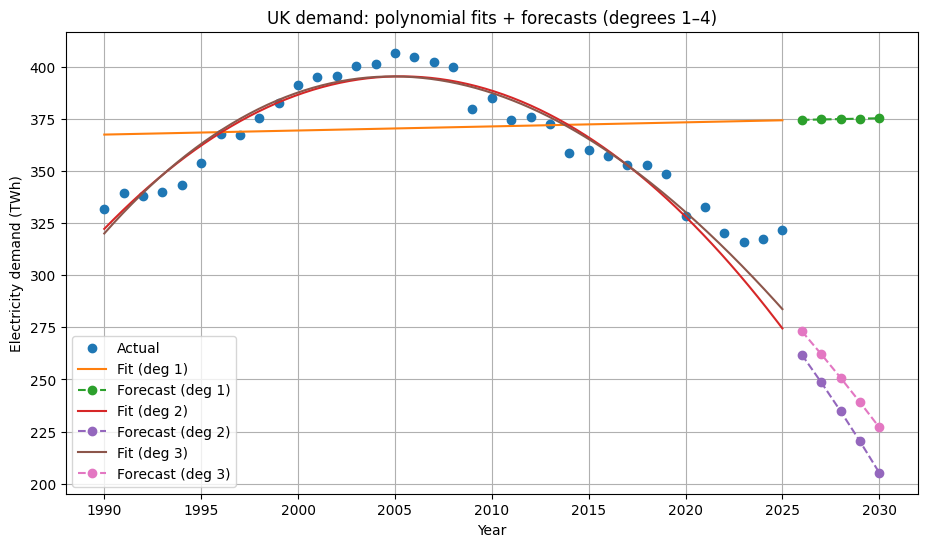

,model,degree,MAE (TWh),RMSE (TWh),MAPE (%)
0,Poly(degree=3),3,18.38,21.56,5.73
1,Poly(degree=2),2,24.44,27.80,7.62
2,Poly(degree=1),1,52.29,52.64,16.30


Best degree by test MAPE: 3


In [77]:

def eval_model(model, X_test, y_test):
    pred = model.predict(X_test)
    mae  = float(mean_absolute_error(y_test, pred))
    mape = float(mean_absolute_percentage_error(y_test, pred))
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    return mae, mape, rmse, pred

degrees = [1, 2, 3]
rows = []

# Prep for smooth fit + future forecast
years_hist = a["year"].astype(int).values
y_hist = a["demand_TWh"].values

grid_years = np.linspace(years_hist.min(), years_hist.max(), 300)
X_grid = pd.DataFrame({"year": grid_years})

horizon = 5
future_years = np.arange(years_hist.max() + 1, years_hist.max() + 1 + horizon)
X_future = pd.DataFrame({"year": future_years})

plt.figure(figsize=(11, 6))
plt.plot(years_hist, y_hist, marker="o", linestyle="None", label="Actual")

for deg in degrees:
    poly = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("lr", LinearRegression())
    ])
    poly.fit(X_train, y_train)

    mae, mape, rmse, _ = eval_model(poly, X_test, y_test)
    rows.append({
        "model": f"Poly(degree={deg})",
        "degree": deg,
        "MAE (TWh)": round(mae, 2),
        "RMSE (TWh)": round(rmse, 2),
        "MAPE (%)": round(mape * 100, 2),
    })

    # Fit curve (smooth) + forecast points
    plt.plot(grid_years, poly.predict(X_grid), label=f"Fit (deg {deg})")
    plt.plot(future_years, poly.predict(X_future), marker="o", linestyle="--", label=f"Forecast (deg {deg})")

plt.xlabel("Year")
plt.ylabel("Electricity demand (TWh)")
plt.title("UK demand: polynomial fits + forecasts (degrees 1–4)")
plt.grid(True)
plt.legend()
plt.show()

poly_results = pd.DataFrame(rows).sort_values(["MAPE (%)", "RMSE (TWh)"]).reset_index(drop=True)
display(poly_results)

best_degree = int(poly_results.iloc[0]["degree"])
print(f"Best degree by test MAPE: {best_degree}")

,area,iso_3_code,year,demand_TWh,type
0,United Kingdom,GBR,2026,273.15,forecast
1,United Kingdom,GBR,2027,262.18,forecast
2,United Kingdom,GBR,2028,250.82,forecast
3,United Kingdom,GBR,2029,239.09,forecast
4,United Kingdom,GBR,2030,227.00,forecast


,area,iso_3_code,year,demand_TWh,type
0,United Kingdom,GBR,2016,356.93,actual
1,United Kingdom,GBR,2017,352.98,actual
2,United Kingdom,GBR,2018,352.87,actual
3,United Kingdom,GBR,2019,348.36,actual
4,United Kingdom,GBR,2020,328.55,actual
5,United Kingdom,GBR,2021,332.64,actual
6,United Kingdom,GBR,2022,320.28,actual
7,United Kingdom,GBR,2023,315.83,actual
8,United Kingdom,GBR,2024,317.35,actual
9,United Kingdom,GBR,2025,321.85,actual


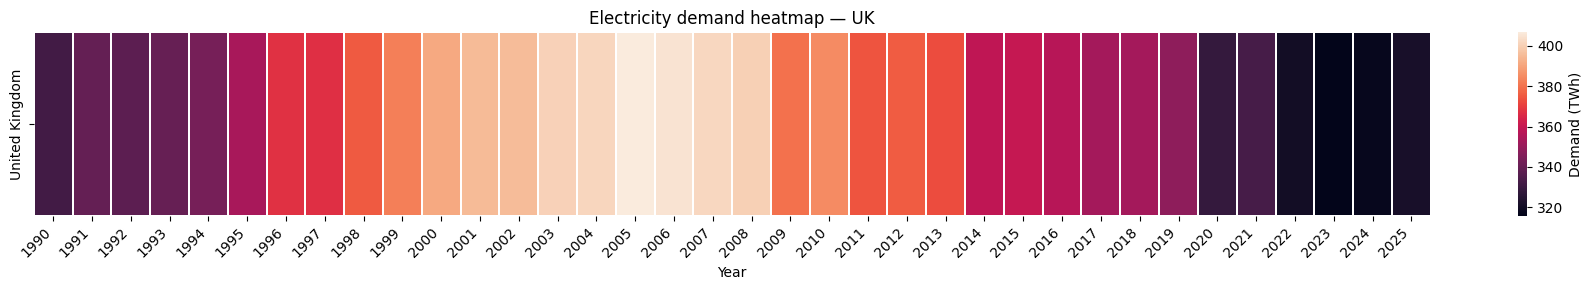

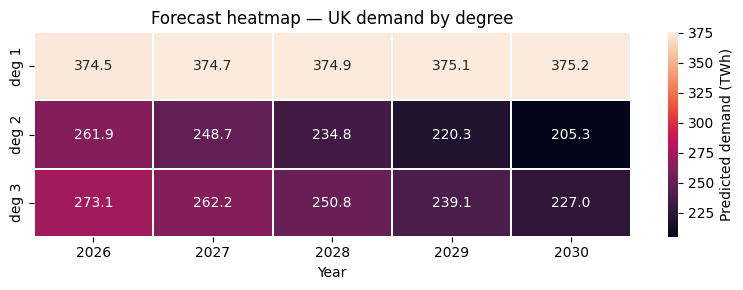

In [78]:


# Fit best model
best_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("lr", LinearRegression())
]).fit(X_train, y_train)

# Forecast next N years with best model
horizon = 5
last_year = int(a["year"].max())
future_years = np.arange(last_year + 1, last_year + 1 + horizon)
X_future = pd.DataFrame({"year": future_years})
future_pred = best_poly.predict(X_future)

forecast_best = pd.DataFrame({
    "area": a["area"].iloc[0],
    "iso_3_code": a["iso_3_code"].iloc[0],
    "year": future_years.astype(int),
    "demand_TWh": future_pred.astype(float),
    "type": "forecast",
})
forecast_best["demand_TWh"] = forecast_best["demand_TWh"].round(2)

# Combine last 10 actual years + best forecast
history_tail = a[["area", "iso_3_code", "year", "demand_TWh"]].tail(10).copy()
history_tail["type"] = "actual"
history_tail["year"] = history_tail["year"].astype(int)
history_tail["demand_TWh"] = history_tail["demand_TWh"].astype(float).round(2)

combined_best = (
    pd.concat([history_tail, forecast_best], ignore_index=True)
      .sort_values(["year", "type"])
)
display(forecast_best)
display(combined_best)

# ---- Heatmap 1: actual demand over years (single row heatmap) ----
heatmap_pivot = a.assign(country=country).pivot(index="country", columns="year", values="demand_TWh")
plt.figure(figsize=(18, 3))
sns.heatmap(heatmap_pivot, annot=False, linewidths=0.3, linecolor="white", cbar_kws={"label": "Demand (TWh)"})
plt.title("Electricity demand heatmap — UK")
plt.xlabel("Year")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---- Heatmap 2: forecast by degree (1–3) ----
heatmap_data = {}
for deg in [1, 2, 3]:
    m = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("lr", LinearRegression())
    ]).fit(X_train, y_train)
    heatmap_data[f"deg {deg}"] = m.predict(X_future).round(2)

forecast_heatmap = pd.DataFrame(heatmap_data, index=future_years).T
forecast_heatmap.index.name = "degree"
forecast_heatmap.columns.name = "year"

plt.figure(figsize=(8, 3))
sns.heatmap(forecast_heatmap, annot=True, fmt=".1f", linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Predicted demand (TWh)"})
plt.title("Forecast heatmap — UK demand by degree")
plt.xlabel("Year")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [79]:
import os

target = "Copy of Energy Consumption Forecasting For Ai driven Data center.ipynb"
matches = []

for root, _, files in os.walk("/content/drive/MyDrive"):
    if target in files:
        matches.append(os.path.join(root, target))

matches

['/content/drive/MyDrive/Copy of Energy Consumption Forecasting For Ai driven Data center.ipynb']

In [80]:
!git clone https://github.com/Erdos-Projects/spring-2026-forecasting-data-center-energy-consumption.git
%cd spring-2026-forecasting-data-center-energy-consumption

Cloning into 'spring-2026-forecasting-data-center-energy-consumption'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/spring-2026-forecasting-data-center-energy-consumption
